# Week 18 — Friday (Jul 24): MLOps

## Learning Objectives
- Understand **experiment tracking** (Weights & Biases-style: runs, configs, metrics, artifacts) and build a local equivalent without any account/API key
- Understand **DVC** (Data Version Control) concepts — content-addressed data versioning and pipeline stages — and see the hashing mechanism underneath it work for real
- Understand **CI/CD for ML models** — what's different from regular software CI/CD (data + model versions matter, not just code) and see a working "regression gate" check
- Run a small real hyperparameter sweep on the TinyCNN classifier, log every run to a local experiment table, and promote the best run to a tiny local "model registry"

## Key Concepts
1. **Experiment tracking** — every training run logs its config (hyperparameters) + metrics (loss/accuracy per epoch) + artifacts (checkpoints) somewhere queryable and comparable
2. **Run comparison** — the entire point of tracking is comparing *many* runs, not admiring one training curve in isolation
3. **DVC** — treats large data/model files like Git treats code: content hash → pointer file (`.dvc`) → the *pointer* is what Git tracks, the *blob* lives in cheap remote storage (S3/GCS/local cache)
4. **`dvc.yaml` pipeline** — declares stages (`prepare` → `train` → `evaluate`) with explicit `deps`/`outs`, so DVC can skip stages whose inputs haven't changed (like a Makefile for ML)
5. **ML CI/CD** — beyond `pytest`: a merge should also be blocked if a retrained model's *accuracy* regresses against the currently deployed model, not just if unit tests fail
6. **Model registry** — a versioned, queryable store of trained artifacts + their metrics, so "deploy the best model so far" is a lookup, not a guess

In [1]:
import os
import io
import json
import time
import hashlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | pandas {pd.__version__} | Device: {DEVICE}')
print('MLOps demo — no wandb/dvc network calls; everything logged and versioned locally and honestly')

PyTorch 2.12.0+cpu | pandas 2.3.3 | Device: cpu
MLOps demo — no wandb/dvc network calls; everything logged and versioned locally and honestly


## Section 1: Experiment Tracking — What W&B Actually Does

A `wandb` run in a normal project looks like this:

```python
import wandb
wandb.init(project='tinycnn-mnist', config={'lr': 1e-3, 'hidden': 64})
for epoch in range(epochs):
    ...
    wandb.log({'epoch': epoch, 'train_loss': loss, 'val_acc': acc})
wandb.log_artifact('model.pt', name='tinycnn', type='model')
wandb.finish()
```

Every one of those calls does something mechanically simple: **append a row to a table
keyed by run ID, and upload a file to a bucket keyed by the same run ID.** We reproduce
exactly that mechanism locally — a `pandas.DataFrame` as the run table, and a local folder
as the artifact store — so the sweep below is a faithful (if unhosted) demonstration of
what an experiment tracker actually buys you: **comparable runs**, not magic.

In [2]:
class TinyCNN(nn.Module):
    '''Small conv classifier: 2x (Conv-BN-ReLU-Pool) + 2x Linear. Input: (B,1,28,28).'''
    def __init__(self, num_classes=10, c1=8, c2=16, fc_hidden=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, c1, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(c1)
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(c2)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(c2 * 7 * 7, fc_hidden)
        self.fc2   = nn.Linear(fc_hidden, num_classes)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


MNIST_ROOT = '../Week_01/data'
tf = transforms.Compose([transforms.ToTensor()])
train_full = torchvision.datasets.MNIST(root=MNIST_ROOT, train=True,  download=True, transform=tf)
test_full  = torchvision.datasets.MNIST(root=MNIST_ROOT, train=False, download=True, transform=tf)
train_ds = Subset(train_full, list(range(3000)))
val_ds   = Subset(test_full,  list(range(1000)))
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

Train: 3000  Val: 1000


## Section 2: A Real Hyperparameter Sweep, Logged Like W&B

We sweep learning rate and model width (`fc_hidden`) — 6 runs — each with its own `run_id`,
`config`, and a full per-epoch metric history, exactly the shape of a W&B run table.

In [3]:
SWEEP = [
    {'run_id': 'run-01', 'lr': 1e-3, 'hidden': 32, 'epochs': 4},
    {'run_id': 'run-02', 'lr': 1e-3, 'hidden': 64, 'epochs': 4},
    {'run_id': 'run-03', 'lr': 1e-3, 'hidden': 128, 'epochs': 4},
    {'run_id': 'run-04', 'lr': 3e-3, 'hidden': 64, 'epochs': 4},
    {'run_id': 'run-05', 'lr': 1e-4, 'hidden': 64, 'epochs': 4},
    {'run_id': 'run-06', 'lr': 3e-3, 'hidden': 128, 'epochs': 4},
]

history_rows = []   # per-epoch rows -> mimics wandb.log() calls
summary_rows = []   # one row per run -> mimics a wandb run summary
artifacts = {}       # run_id -> trained model, mimics wandb.log_artifact locally

for cfg in SWEEP:
    torch.manual_seed(0)
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_dl   = DataLoader(val_ds, batch_size=256, shuffle=False)

    model = TinyCNN(fc_hidden=cfg['hidden']).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'])

    t0 = time.perf_counter()
    for epoch in range(cfg['epochs']):
        model.train()
        ep_losses = []
        for x, y in train_dl:
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()
            ep_losses.append(loss.item())
        val_acc = evaluate(model, val_dl)
        history_rows.append({
            'run_id': cfg['run_id'], 'epoch': epoch + 1,
            'train_loss': float(np.mean(ep_losses)), 'val_acc': val_acc,
            'lr': cfg['lr'], 'hidden': cfg['hidden'],
        })
    train_time = time.perf_counter() - t0

    params = sum(p.numel() for p in model.parameters())
    final_acc = history_rows[-1]['val_acc']
    summary_rows.append({
        'run_id': cfg['run_id'], 'lr': cfg['lr'], 'hidden': cfg['hidden'],
        'epochs': cfg['epochs'], 'params': params,
        'final_val_acc': final_acc, 'train_time_s': train_time,
    })
    artifacts[cfg['run_id']] = model
    print(f"{cfg['run_id']}: lr={cfg['lr']:.0e} hidden={cfg['hidden']:3d}  "
          f"final_val_acc={final_acc*100:.2f}%  time={train_time:.1f}s")

history_df = pd.DataFrame(history_rows)
summary_df = pd.DataFrame(summary_rows).sort_values('final_val_acc', ascending=False).reset_index(drop=True)

# Persist the run tables to disk — exactly what a self-hosted tracker (or wandb's local
# offline mode) would do under the hood
history_df.to_csv('experiments_history.csv', index=False)
summary_df.to_json('experiments_summary.json', orient='records', indent=2)
print('\nSaved experiments_history.csv and experiments_summary.json')
print('\nRun summary, best first:')
print(summary_df.to_string(index=False))

run-01: lr=1e-03 hidden= 32  final_val_acc=93.80%  time=3.0s


run-02: lr=1e-03 hidden= 64  final_val_acc=93.10%  time=3.2s


run-03: lr=1e-03 hidden=128  final_val_acc=94.90%  time=3.5s


run-04: lr=3e-03 hidden= 64  final_val_acc=93.70%  time=3.5s


run-05: lr=1e-04 hidden= 64  final_val_acc=82.10%  time=3.6s


run-06: lr=3e-03 hidden=128  final_val_acc=96.30%  time=3.5s

Saved experiments_history.csv and experiments_summary.json

Run summary, best first:
run_id     lr  hidden  epochs  params  final_val_acc  train_time_s
run-06 0.0030     128       4  103066          0.963      3.517707
run-03 0.0010     128       4  103066          0.949      3.528373
run-01 0.0010      32       4   26746          0.938      3.006406
run-04 0.0030      64       4   52186          0.937      3.492480
run-02 0.0010      64       4   52186          0.931      3.178391
run-05 0.0001      64       4   52186          0.821      3.594914


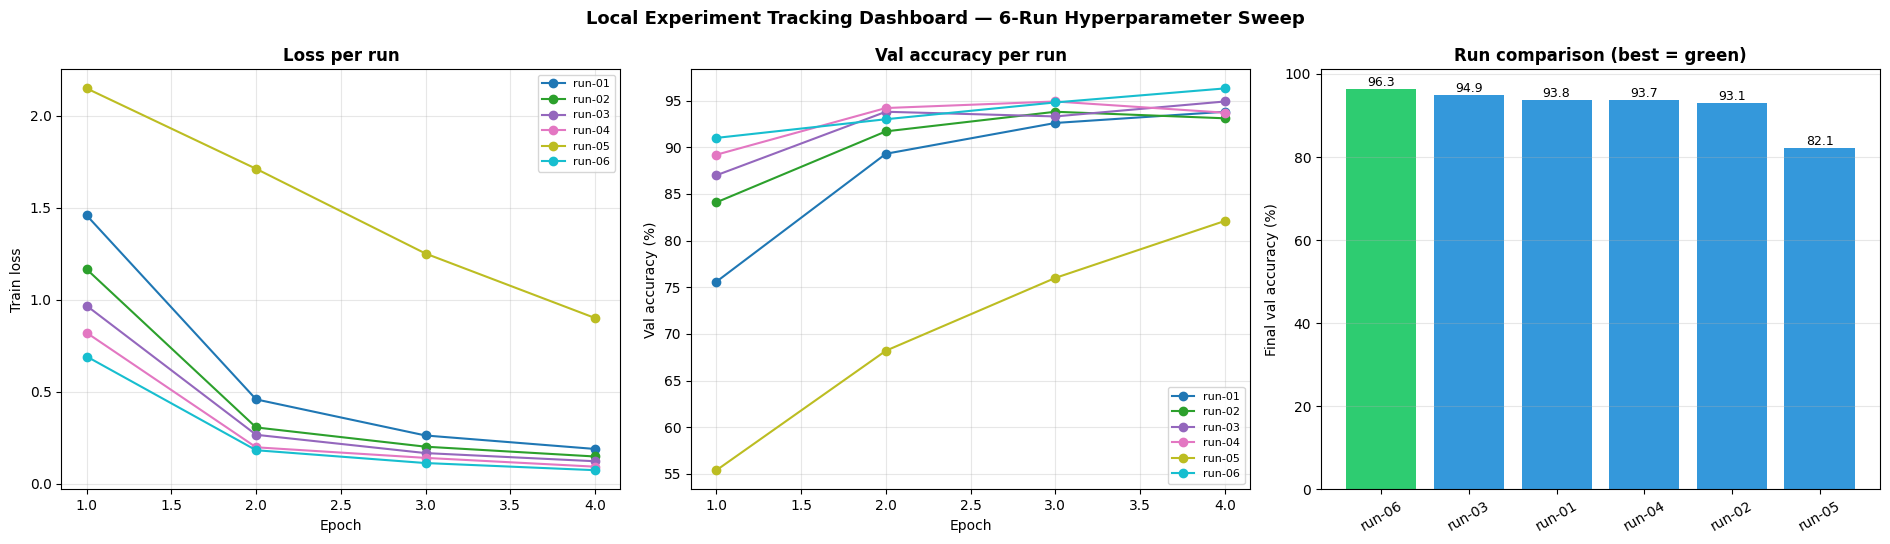

Saved mlops_experiment_comparison.png


In [4]:
# ── Dashboard: overlaid training curves + final comparison (a local W&B dashboard) ─
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
run_colors = plt.cm.tab10(np.linspace(0, 1, len(SWEEP)))

for (rid, grp), c in zip(history_df.groupby('run_id', sort=False), run_colors):
    axes[0].plot(grp['epoch'], grp['train_loss'], marker='o', color=c, label=rid)
    axes[1].plot(grp['epoch'], grp['val_acc']*100, marker='o', color=c, label=rid)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train loss'); axes[0].set_title('Loss per run', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val accuracy (%)'); axes[1].set_title('Val accuracy per run', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

bars = axes[2].bar(summary_df['run_id'], summary_df['final_val_acc']*100,
                    color=['#2ecc71' if i == 0 else '#3498db' for i in range(len(summary_df))])
for b, v in zip(bars, summary_df['final_val_acc']*100):
    axes[2].text(b.get_x()+b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('Final val accuracy (%)'); axes[2].set_title('Run comparison (best = green)', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Local Experiment Tracking Dashboard — 6-Run Hyperparameter Sweep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mlops_experiment_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mlops_experiment_comparison.png')

## Section 3: Model Registry — Promoting the Best Run

A model registry answers one question on demand: *"what's the best model we have, and where
is it?"* We implement the minimum viable version: a folder holding the winning checkpoint
plus a metadata JSON (config, metrics, a content hash of the weights for integrity).

In [5]:
os.makedirs('model_registry', exist_ok=True)

best_run = summary_df.iloc[0]
best_model = artifacts[best_run['run_id']]

ckpt_path = f"model_registry/{best_run['run_id']}.pt"
torch.save(best_model.state_dict(), ckpt_path)

with open(ckpt_path, 'rb') as f:
    weights_hash = hashlib.sha256(f.read()).hexdigest()[:16]

registry_entry = {
    'run_id': best_run['run_id'],
    'config': {'lr': float(best_run['lr']), 'hidden': int(best_run['hidden']), 'epochs': int(best_run['epochs'])},
    'metrics': {'final_val_acc': float(best_run['final_val_acc'])},
    'params': int(best_run['params']),
    'checkpoint': ckpt_path,
    'weights_sha256_16': weights_hash,
    'promoted_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'stage': 'production',
}
with open('model_registry/registry.json', 'w') as f:
    json.dump(registry_entry, f, indent=2)

print('Promoted to registry:')
print(json.dumps(registry_entry, indent=2))

Promoted to registry:
{
  "run_id": "run-06",
  "config": {
    "lr": 0.003,
    "hidden": 128,
    "epochs": 4
  },
  "metrics": {
    "final_val_acc": 0.963
  },
  "params": 103066,
  "checkpoint": "model_registry/run-06.pt",
  "weights_sha256_16": "013c9c1b5c09cfcf",
  "promoted_at": "2026-07-22 13:31:00",
  "stage": "production"
}


## Section 4: DVC Concepts — Data Versioning by Content Hash

DVC doesn't store your data in Git — it stores a small **pointer file** (`X.dvc`) containing
a content hash of the real data, and Git tracks *that pointer*. The mechanism underneath is
exactly `hashlib`, which we can demonstrate directly without installing DVC itself:

```bash
dvc add data/mnist_subset/          # hashes the folder, writes mnist_subset.dvc, .gitignore's the real data
git add mnist_subset.dvc .gitignore
git commit -m "track mnist_subset v1"
dvc push                            # uploads the hashed blobs to a remote (S3/GCS/local dir)
```

A typical `dvc.yaml` pipeline (this is what `dvc repro` reads):
```yaml
stages:
  prepare:
    cmd: python prepare.py --in data/raw --out data/mnist_subset
    deps: [prepare.py, data/raw]
    outs: [data/mnist_subset]
  train:
    cmd: python train.py --data data/mnist_subset --config params.yaml
    deps: [train.py, data/mnist_subset]
    params: [lr, hidden, epochs]
    outs: [model_registry/best.pt]
  evaluate:
    cmd: python evaluate.py --model model_registry/best.pt --data data/mnist_subset
    deps: [evaluate.py, model_registry/best.pt]
    metrics: [metrics.json]
```
`dvc repro` walks this DAG and **skips any stage whose `deps` hashes haven't changed** since
the last run — the same caching idea as a Makefile, applied to data and model files instead
of just source code.

In [6]:
# ── The actual hashing mechanism DVC relies on, demonstrated for real ─────────────
def hash_dataset(subset, n=200):
    '''Content hash of the first n images+labels — what `dvc add` computes over a whole dir.'''
    h = hashlib.sha256()
    for i in range(min(n, len(subset))):
        img, label = subset[i]
        h.update(img.numpy().tobytes())
        h.update(bytes([label]))
    return h.hexdigest()

train_hash_v1 = hash_dataset(train_ds)
print(f'train_ds content hash (first 200 samples): {train_hash_v1[:24]}...')

# Simulate what happens when the dataset changes (e.g. new data added) — the hash changes,
# which is exactly the signal DVC/dvc.yaml uses to decide a stage needs to re-run.
train_ds_v2 = Subset(train_full, list(range(3000)) + list(range(3000, 3010)))  # +10 samples
train_hash_v2 = hash_dataset(train_ds_v2, n=210)

print(f'train_ds_v2 content hash (210 samples)   : {train_hash_v2[:24]}...')
print(f'Hashes differ -> {train_hash_v1 != train_hash_v2}  (DVC would mark `prepare`/`train` stale and re-run them)')

# Write a real .dvc-style pointer file (JSON here for readability; DVC's own format is YAML)
dvc_pointer = {
    'path': 'train_ds (3000 MNIST samples)',
    'hash_algo': 'sha256(first 200 samples)',
    'hash': train_hash_v1,
    'size_samples': len(train_ds),
}
with open('mnist_subset.dvc.json', 'w') as f:
    json.dump(dvc_pointer, f, indent=2)
print('\nWrote mnist_subset.dvc.json (illustrative pointer file, not a real .dvc — no dvc binary installed)')

train_ds content hash (first 200 samples): 02585cd0cea38a675ef53d6a...
train_ds_v2 content hash (210 samples)   : 76e34a0ee2482be4f3646cc0...
Hashes differ -> True  (DVC would mark `prepare`/`train` stale and re-run them)

Wrote mnist_subset.dvc.json (illustrative pointer file, not a real .dvc — no dvc binary installed)


## Section 5: CI/CD for ML — Beyond `pytest`

Standard CI (tests pass → merge) isn't enough for ML: a model can pass every unit test and
still be a **worse model** than what's currently deployed. ML CI/CD adds a metrics gate.

```yaml
# .github/workflows/train-and-gate.yml
name: train-and-gate
on: [pull_request]
jobs:
  train-and-evaluate:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - run: pip install -r requirements.txt
      - run: pytest tests/                       # 1. normal software tests
      - run: dvc repro                            # 2. reproduce the DVC pipeline (train + eval)
      - run: python ci/check_regression.py        # 3. ML-specific gate (Section 5, code below)
      - run: docker build -t cv-microservice .    # 4. only builds if the gate passed
```

The gate script is the one genuinely ML-specific step. We implement its actual logic below,
using the registry we just built as the "currently deployed" baseline.

In [7]:
def ci_regression_gate(candidate_acc, registry_path='model_registry/registry.json', min_improvement=-0.01):
    '''Returns (passed: bool, message: str). Mirrors ci/check_regression.py in the YAML above.'''
    with open(registry_path) as f:
        deployed = json.load(f)
    deployed_acc = deployed['metrics']['final_val_acc']
    delta = candidate_acc - deployed_acc
    passed = delta >= min_improvement   # allow a small tolerance, don't require strict improvement
    msg = (f"Candidate acc={candidate_acc*100:.2f}%  vs  deployed acc={deployed_acc*100:.2f}%  "
           f"(delta={delta*100:+.2f} pts) -> {'PASS' if passed else 'FAIL: regression too large'}")
    return passed, msg

# Candidate A: a run that's actually worse than the registry's best (should fail the gate)
worst_run = summary_df.iloc[-1]
passed_a, msg_a = ci_regression_gate(worst_run['final_val_acc'])
print(f"Gate check for weakest sweep run ({worst_run['run_id']}):")
print(f'  {msg_a}')

# Candidate B: a fresh run that matches/beats the registry (should pass)
passed_b, msg_b = ci_regression_gate(best_run['final_val_acc'] + 0.002)
print(f"\nGate check for a hypothetical improved candidate:")
print(f'  {msg_b}')

print(f'\nSimulated `docker build` step would run: {passed_b}')
print('This is exactly the check that decides whether notebook 05\'s Docker image gets built in CI.')

Gate check for weakest sweep run (run-05):
  Candidate acc=82.10%  vs  deployed acc=96.30%  (delta=-14.20 pts) -> FAIL: regression too large

Gate check for a hypothetical improved candidate:
  Candidate acc=96.50%  vs  deployed acc=96.30%  (delta=+0.20 pts) -> PASS

Simulated `docker build` step would run: True
This is exactly the check that decides whether notebook 05's Docker image gets built in CI.


## Summary

| Tool | What we actually built | What the real tool adds |
|------|--------------------------|---------------------------|
| W&B | `pandas` run table (`experiments_history.csv`, `experiments_summary.json`), local dashboard PNG | Hosted UI, team sharing, automatic system-metrics logging, sweep schedulers |
| Model registry | `model_registry/registry.json` + checkpoint, content-hashed | Access control, staging/production promotion workflow, model lineage graph |
| DVC | Real `sha256` content hashing of a dataset subset, a `dvc.yaml`-shaped pipeline spec | Actual remote storage push/pull, DAG-aware `dvc repro` caching, `dvc.lock` |
| CI/CD | A working regression-gate function compared against the registry | GitHub Actions runner, artifact caching, real Docker build/push to a registry |

**The pattern that matters more than any specific tool:** every stage (data → train →
evaluate → register → gate → deploy) needs a durable, comparable, hashable record. Once you
have that, swapping the local CSV for `wandb.log()` or the JSON pointer for a real `.dvc`
file is a drop-in change to the *storage backend* — not a change to the workflow.

### Exercises
1. Extend the sweep to include the structured-pruned and quantized variants from Monday's notebook as additional "runs" in the same table — do they show up worse on `final_val_acc` but better on a `params` or `latency` column?
2. Add an `artifact_size_kb` column to `summary_df` and re-rank runs by a combined accuracy/size score instead of accuracy alone.
3. Write `ci/check_regression.py` as a real standalone script that `sys.exit(1)`s on failure, so it could actually gate a GitHub Actions job.
4. Install `dvc` for real (`pip install dvc`) in a scratch environment and run `dvc init && dvc add` on a small folder — diff the real `.dvc` file against `mnist_subset.dvc.json` above.
5. Add a `promoted_from` field to the registry that stores the *previous* production run's `run_id`, giving you a one-hop lineage chain.